# Thesis graphs

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import textwrap
import numpy as np
import random
import torch
from prsi.env import PrsiEnv
from prsi.agents.baselines import RandomAgent, GreedyAgent

from agents.dqn import DQNAgent
from agents.reinforce import REINFORCEAgent
from agents.ddqn import DoubleDQNAgent
from agents.monte_carlo import MonteCarloAgent
from agents.q_learning import QLearningAgent

In [2]:
def evaluate_agent(agent, episodes=1000, seed=42, opponent=GreedyAgent()):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    env = PrsiEnv(opponent=opponent)
    return agent.evaluate(env, episodes, opponent)

def plot_and_eval_algorithm(algo_name, agent_class, strategies_dir):
    if not os.path.exists(strategies_dir):
        print(f"Directory {strategies_dir} does not exist.")
        return

    strategies = sorted([d for d in os.listdir(strategies_dir) if os.path.isdir(os.path.join(strategies_dir, d))])
    
    # Increased height slightly to accommodate the legend at the bottom
    fig, ax = plt.subplots(figsize=(12, 10))
    results = []
    
    for strategy in strategies:
        strategy_path = os.path.join(strategies_dir, strategy)
        log_path = os.path.join(strategy_path, "logs.csv")
        if not os.path.exists(log_path):
            continue
            
        df = pd.read_csv(log_path)
            
        # Wrap the long strategy names so they don't stretch the legend horizontally
        wrapped_label = textwrap.fill(strategy, width=60)
        
        ax.plot(df["episode"], df["batch_win_rate"], label=wrapped_label)
        
        # Evaluate
        try:
            agent = agent_class(path=strategy_path)
            win_rate = evaluate_agent(agent)
            results.append((win_rate, strategy, agent))
            print(f"Strategy {strategy}: {win_rate:.2%} win rate")
        except Exception as e:
            print(f"Could not evaluate {strategy}: {e}")
            
    ax.set_title(f"{algo_name} Training Win Rate")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Batch Win Rate")
    
    # Fix Y-axis to always be 0 to 1, and format it as percentages (0% to 100%)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.8, zorder=0)
    
    # Place the legend below the graph, split into 2 columns if there are many lines
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2, fontsize=9)
    ax.grid(True)
    
    # Use tight_layout but leave a 25% margin at the bottom specifically for the legend
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    if not results:
        print(f"No evaluated strategies found for {algo_name}")
        return

    best_win_rate, best_strategy, best_agent = max(results, key=lambda x: x[0])
    
    # Eval against RandomAgent
    random_win_rate = evaluate_agent(best_agent, opponent=RandomAgent())

    print(f"\nBest strategy: {best_strategy}.")
    print(f"Best {algo_name} agent against GreedyAgent: {best_win_rate:.2%} win rate")
    print(f"Best {algo_name} agent against RandomAgent: {random_win_rate:.2%} win rate")

## Monte Carlo

Loading model from agent_strategies/monte_carlo/seed42-eps0.05-gamma0.99-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 477/1000 wins (47.70%)
Strategy seed42-eps0.05-gamma0.99-hand_count_truncated-trunc4-sub_specials: 47.70% win rate
Loading model from agent_strategies/monte_carlo/seed42-eps0.1-gamma0.99-ev-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 484/1000 wins (48.40%)
Strategy seed42-eps0.1-gamma0.99-ev-hand_count_truncated-trunc4-sub_specials: 48.40% win rate
Loading model from agent_strategies/monte_carlo/seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 498/1000 wins (49.80%)
Strategy seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials: 49.80% win rate
Loading model from agent_strategies/monte_carlo/seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials/model.pkl
Model 

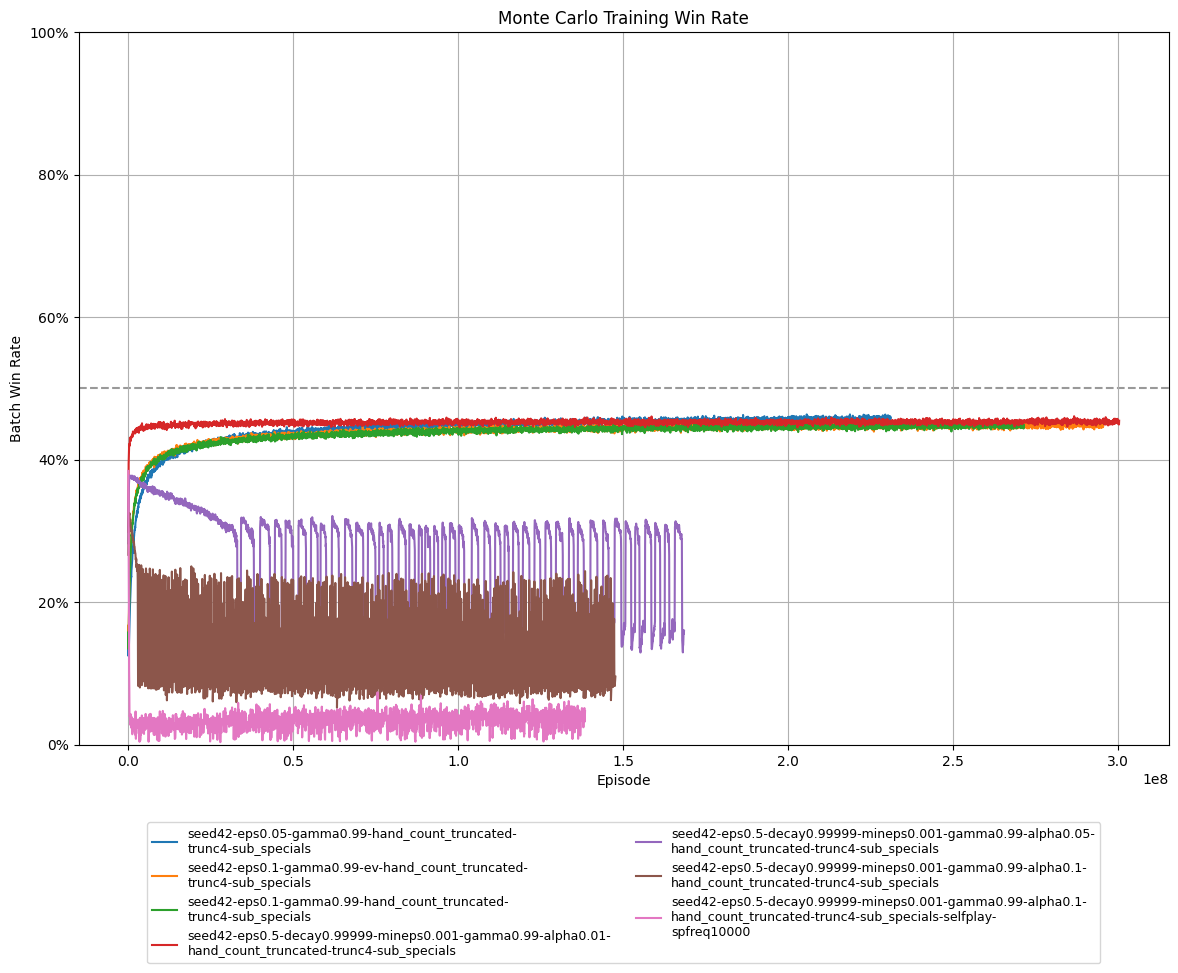

Evaluation: 920/1000 wins (92.00%)

Best strategy: seed42-eps0.1-gamma0.99-hand_count_truncated-trunc4-sub_specials.
Best Monte Carlo agent against GreedyAgent: 49.80% win rate
Best Monte Carlo agent against RandomAgent: 92.00% win rate


In [3]:
plot_and_eval_algorithm("Monte Carlo", MonteCarloAgent, "agent_strategies/monte_carlo")

## Q-Learning

Loading model from agent_strategies/q_learning/seed42-eps0.05-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 335/1000 wins (33.50%)
Strategy seed42-eps0.05-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials: 33.50% win rate
Loading model from agent_strategies/q_learning/seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 401/1000 wins (40.10%)
Strategy seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials: 40.10% win rate
Loading model from agent_strategies/q_learning/seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials/model.pkl
Model loaded successfully!
Evaluation: 348/1000 wins (34.80%)
Strategy seed42-eps0.5-decay0.99999-mineps0.001-gamma0.99-alpha0.01-hand_count_truncated-trunc4-sub_specials: 34.80% win rate
Loading model from agent_strategies/q_learning/seed42-eps0.5-decay0

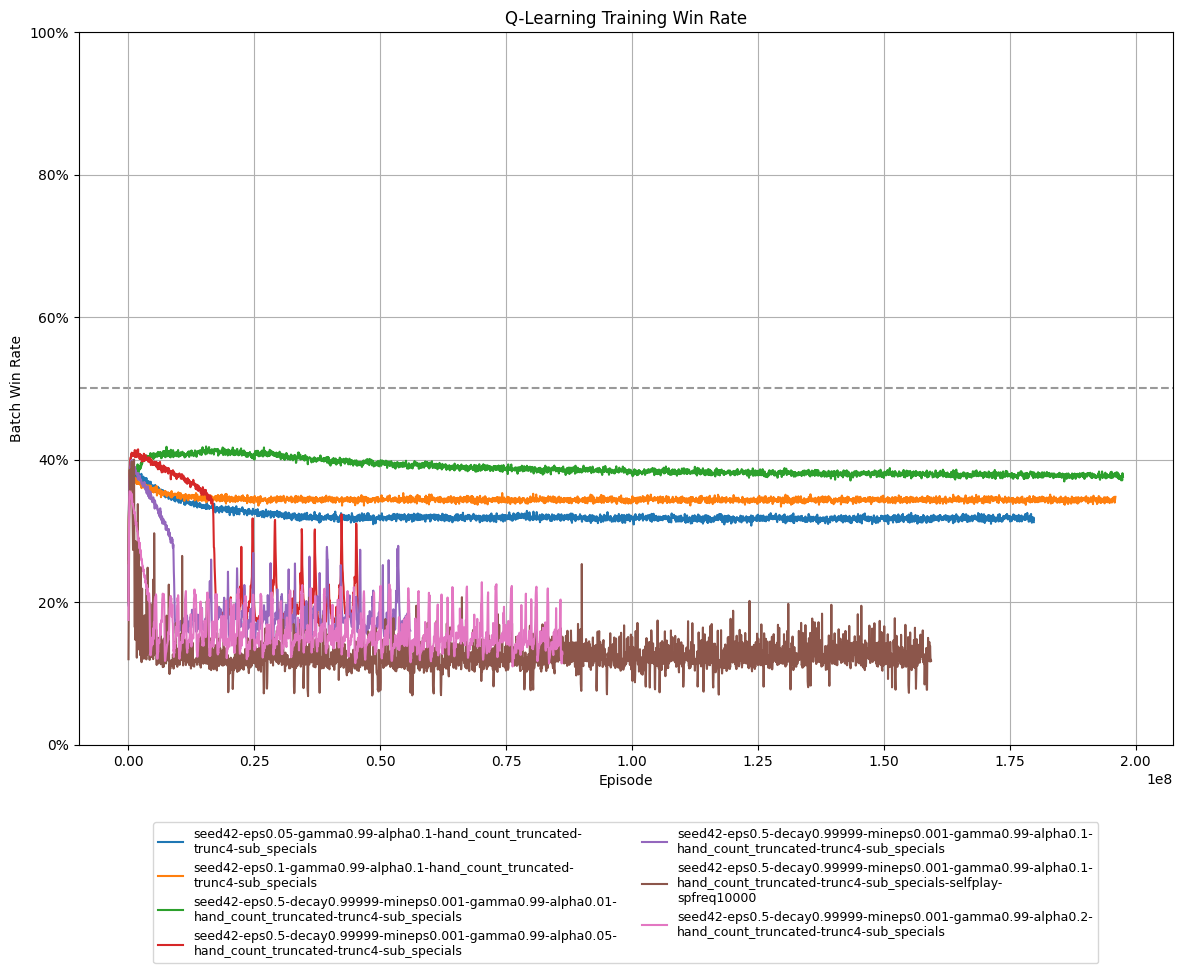

Evaluation: 880/1000 wins (88.00%)

Best strategy: seed42-eps0.1-gamma0.99-alpha0.1-hand_count_truncated-trunc4-sub_specials.
Best Q-Learning agent against GreedyAgent: 40.10% win rate
Best Q-Learning agent against RandomAgent: 88.00% win rate


In [4]:
plot_and_eval_algorithm("Q-Learning", QLearningAgent, "agent_strategies/q_learning")

## DQN

Loading model from agent_strategies/dqn/seed42-eps0.05-gamma0.99-lr5e-05-bs32-targ100-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards 

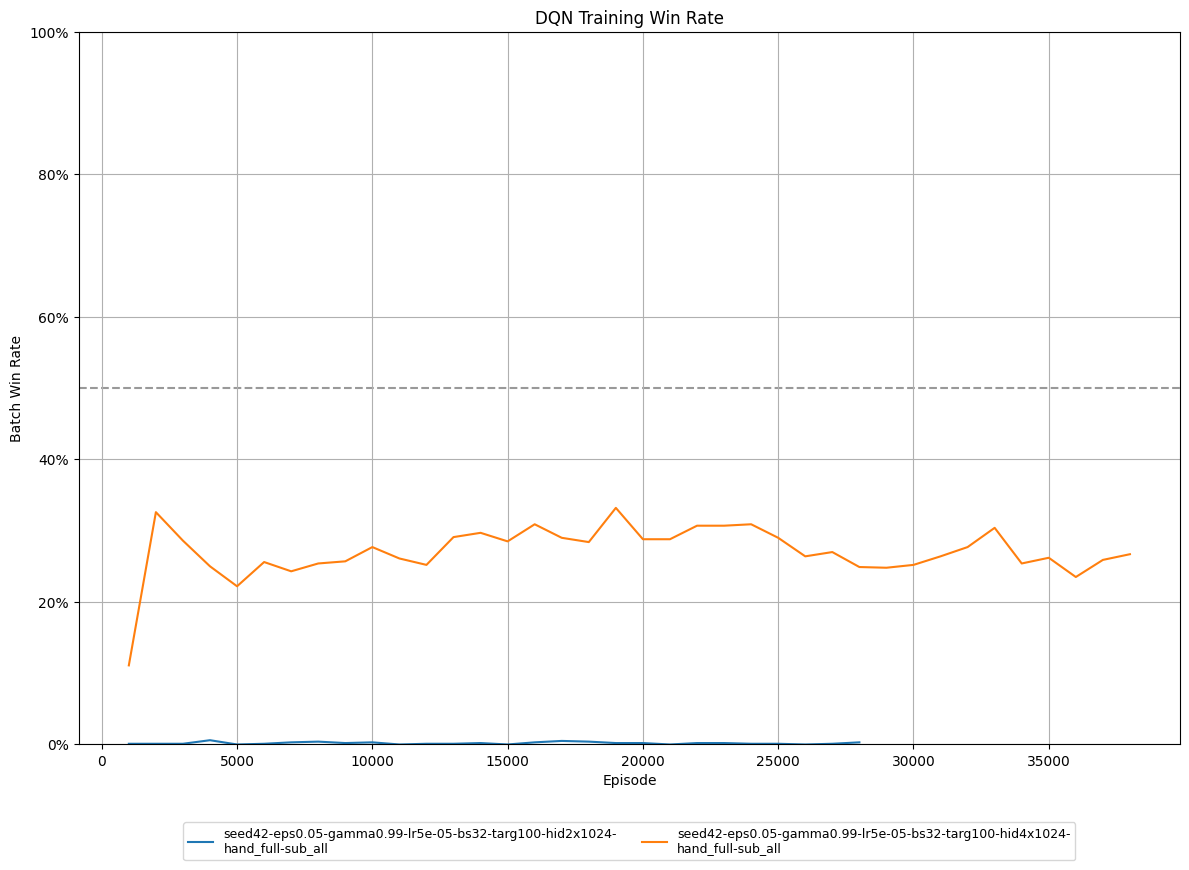

No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available t

In [5]:
plot_and_eval_algorithm("DQN", DQNAgent, "agent_strategies/dqn")

## Double DQN

Loading model from agent_strategies/ddqn/seed42-eps0.05-gamma0.99-lr5e-05-bs32-targ100-hid4x1024-hand_full-sub_all/model.pth
Model loaded successfully!
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards

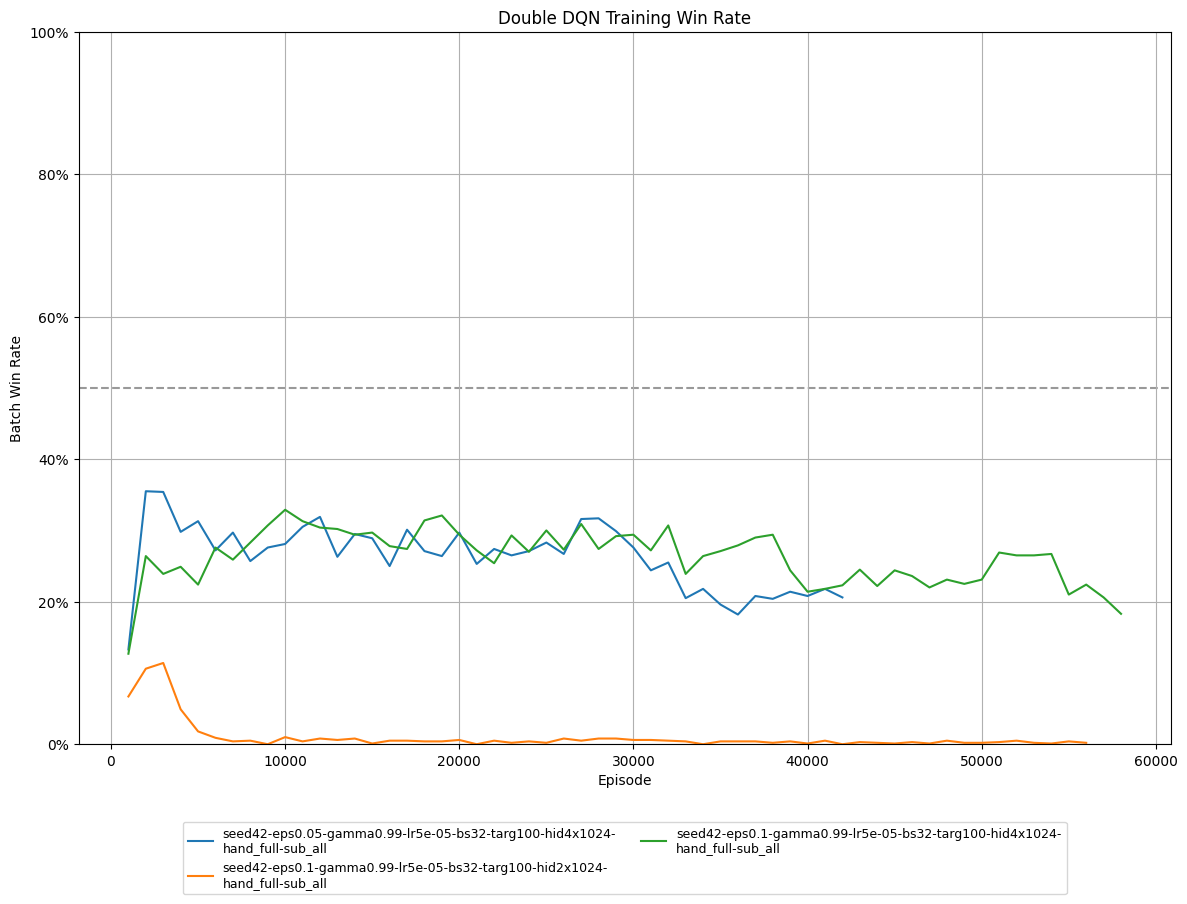

No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available to draw.
No cards available t

In [6]:
plot_and_eval_algorithm("Double DQN", DoubleDQNAgent, "agent_strategies/ddqn")

## REINFORCE

Loading model from agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.001-base-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
Evaluation: 551/1000 wins (55.10%)
Strategy seed42-gamma0.99-lr0.0001-bs32-ent0.001-base-hid2x1024-hand_full-sub_all: 55.10% win rate
Loading model from agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.01-base-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
Evaluation: 636/1000 wins (63.60%)
Strategy seed42-gamma0.99-lr0.0001-bs32-ent0.01-base-hid2x1024-hand_full-sub_all: 63.60% win rate
Loading model from agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.01-hid2x1024-hand_full-sub_all/model.pth
Model loaded successfully!
Evaluation: 621/1000 wins (62.10%)
Strategy seed42-gamma0.99-lr0.0001-bs32-ent0.01-hid2x1024-hand_full-sub_all: 62.10% win rate
Loading model from agent_strategies/reinforce/seed42-gamma0.99-lr0.0001-bs32-ent0.05-base-hid2x1024-hand_full-sub_all/model.pth
Model loaded suc

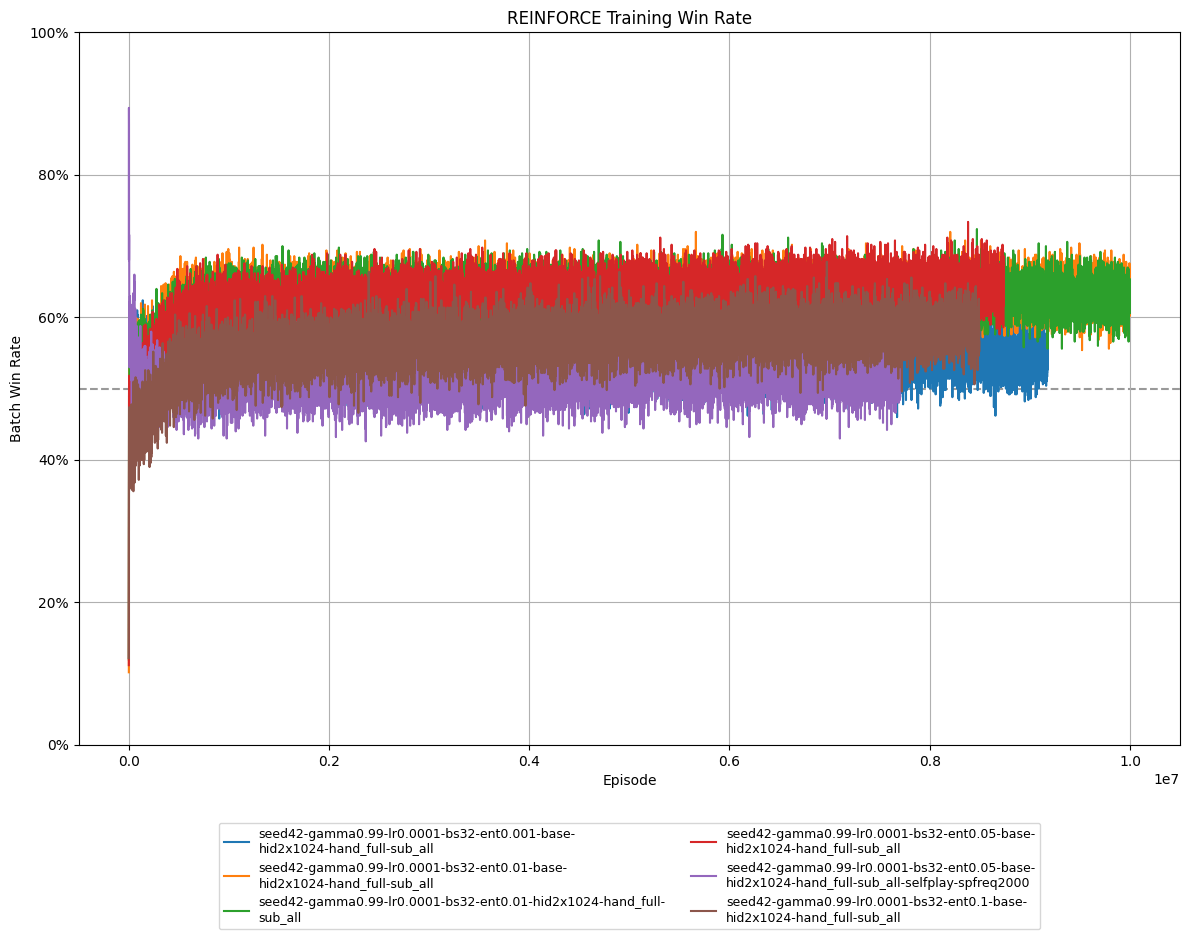

Evaluation: 957/1000 wins (95.70%)

Best strategy: seed42-gamma0.99-lr0.0001-bs32-ent0.05-base-hid2x1024-hand_full-sub_all.
Best REINFORCE agent against GreedyAgent: 64.90% win rate
Best REINFORCE agent against RandomAgent: 95.70% win rate


In [7]:
plot_and_eval_algorithm("REINFORCE", REINFORCEAgent, "agent_strategies/reinforce")